# Vienna Mobility Map

End-to-end pipeline: pull public transit stop locations from the City of Vienna's open WFS API, clean the data with `geopandas`, and render an interactive map with `folium`.

**Source**: `ogdwien:HALTESTELLEWLOGD` ("Haltestellen Wiener Linien") via `https://data.wien.gv.at/daten/geo`, part of Vienna's Open Government Data catalog.

In [1]:
import sys
sys.path.append("../src")

import matplotlib.pyplot as plt
import contextily as cx

from pipeline import fetch_stops, clean_stops, build_map

## 1. Fetch

`fetch_stops()` issues a WFS `GetFeature` request against the live Vienna endpoint and returns a GeoDataFrame.

In [2]:
stops_raw = fetch_stops()
print(f"Fetched {len(stops_raw)} raw features")
stops_raw.head()

Fetched 1807 raw features


,geometry,OBJECTID,BEZEICHNUNG,WL_NUMMER,SE_ANNO_CAD_DATA
0,POINT (16.38977 48.17379),1,Absberggasse,1,None
1,POINT (16.44890 48.28453),2,Achengasse,2,None
2,POINT (16.38581 48.15293),3,Ada-Christen-Gasse,3,None
3,POINT (16.53512 48.21564),4,Adam-Betz-Gasse,4,None
4,POINT (16.33799 48.14229),5,Adamovichgasse,5,None


## 2. Clean

Drop null geometries/duplicates and rename columns to something readable.

In [3]:
stops = clean_stops(stops_raw)
print(f"{len(stops)} stops after cleaning")
stops.head()

1807 stops after cleaning


,OBJECTID,stop_name,line_number,geometry
0,1,Absberggasse,1,POINT (16.38977 48.17379)
1,2,Achengasse,2,POINT (16.44890 48.28453)
2,3,Ada-Christen-Gasse,3,POINT (16.38581 48.15293)
3,4,Adam-Betz-Gasse,4,POINT (16.53512 48.21564)
4,5,Adamovichgasse,5,POINT (16.33799 48.14229)


## 3. Explore

A quick static plot of stop density across the city before building the interactive version.

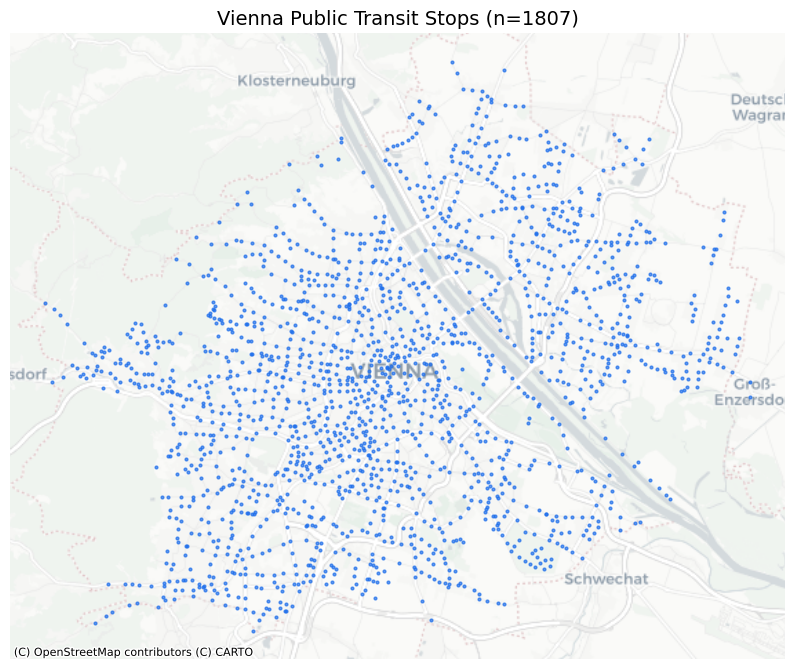

In [4]:
stops_web_mercator = stops.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))
stops_web_mercator.plot(ax=ax, markersize=4, color="#1f6feb", alpha=0.7)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()
ax.set_title(f"Vienna Public Transit Stops (n={len(stops)})", fontsize=14)

fig.savefig("../output/vienna_mobility_map.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. Interactive map

`build_map()` renders every stop as a clickable marker (stop name + line number) on a Folium map.

In [5]:
mobility_map = build_map(stops)
mobility_map

## 5. Export

Save the interactive map as a self-contained HTML file for embedding/linking from the portfolio site.

In [6]:
mobility_map.save("../output/vienna_mobility_map.html")
print("Saved ../output/vienna_mobility_map.html")

Saved ../output/vienna_mobility_map.html
